# YOLO11 + ByteTrack — MOT17 객체 추적 및 라인 카운팅

[MOT17](https://motchallenge.net/) 시퀀스 **MOT17-04-FRCNN** 이미지를 입력으로  
**Ultralytics YOLO11** 탐지 + **ByteTrack** 추적 + **OpenCV** 라인 카운팅 예제입니다.

| 항목 | 설명 |
|------|------|
| 데이터 | `MOT17-04-FRCNN.zip` → `img1/` 이미지 시퀀스 |
| 탐지 | YOLO11 — COCO **person**(class 0) |
| 추적 | ByteTrack (`bytetrack.yaml`) |
| 카운팅 | 수평 기준선 통과 시 1회 카운트 (동일 ID 중복 없음) |
| 종료 | OpenCV 창에서 **ESC** 키 |

## 0. 환경 설정

In [ ]:
# %pip install -U ultralytics opencv-python matplotlib pandas

import zipfile
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import torch
from IPython.display import Image as IPImage, display
from ultralytics import YOLO, __version__

# 한글 폰트 설정 (matplotlib 시각화용)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# Colab / 로컬 환경 자동 감지
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# GPU 사용 가능 시 cuda, 아니면 cpu
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 프로젝트 루트 경로 탐색 (zip 파일 위치 기준)
ROOT = Path("/content") if IN_COLAB else Path.cwd()
if not (ROOT / "MOT17-04-FRCNN.zip").exists():
    for parent in [ROOT, *ROOT.parents]:
        if (parent / "MOT17-04-FRCNN.zip").exists():
            ROOT = parent
            break

# --- 경로 및 하이퍼파라미터 ---
ZIP_PATH = ROOT / "MOT17-04-FRCNN.zip"       # 원본 압축 파일
DATA_ROOT = ROOT / "MOT17-04-FRCNN"          # 압축 해제 디렉터리
IMG_DIR = DATA_ROOT / "img1"                 # 이미지 시퀀스 폴더
GT_PATH = DATA_ROOT / "gt" / "gt.txt"        # MOT GT 어노테이션
EDA_DIR = DATA_ROOT / "eda"                  # EDA 결과 저장 (선택)

MODEL_NAME = "yolo11s.pt"      # YOLO11 small 사전학습 가중치
TRACKER = "bytetrack.yaml"     # ByteTrack 추적기 설정 파일
PERSON_CLASS = 0                 # COCO 클래스 ID: person
CONF_THRESH = 0.25               # 탐지 신뢰도 임계값
IOU_THRESH = 0.5                 # NMS IoU 임계값
LINE_Y_RATIO = 0.55              # 프레임 높이 대비 수평 카운트 기준선 위치 (0~1)

print(f"환경       : {'Colab' if IN_COLAB else '로컬'}")
print(f"Ultralytics: {__version__}")
print(f"OpenCV     : {cv2.__version__}")
print(f"Device     : {DEVICE}")
print(f"ROOT       : {ROOT.resolve()}")


환경       : 로컬
Ultralytics: 8.4.46
OpenCV     : 4.11.0
Device     : cuda
ROOT       : C:\MyCursorLab\06_Object_Detection


## 1. 데이터 준비 (압축 해제)

In [3]:
def data_is_ready(root: Path) -> bool:
    """img1 이미지와 gt.txt가 존재하면 압축 해제 완료로 판단."""
    img_dir = root / "img1"
    gt_file = root / "gt" / "gt.txt"
    return img_dir.exists() and len(list(img_dir.glob("*.jpg"))) > 0 and gt_file.exists()


def extract_mot17_zip(zip_path: Path, extract_to: Path, force: bool = False) -> None:
    """MOT17-04-FRCNN.zip을 extract_to에 압축 해제."""
    if not zip_path.exists():
        raise FileNotFoundError(f"압축 파일이 없습니다: {zip_path}")
    extract_to.mkdir(parents=True, exist_ok=True)
    # 이미 준비된 경우 스킵 (force=True 시 무조건 재해제)
    if not force and data_is_ready(extract_to):
        print("이미 압축 해제되어 있습니다.")
        return
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(extract_to)
    print(f"압축 해제 완료: {extract_to.resolve()}")


# 압축 해제 실행
extract_mot17_zip(ZIP_PATH, DATA_ROOT)

# 프레임 순서대로 정렬 (000001.jpg, 000002.jpg, ...)
image_paths = sorted(IMG_DIR.glob("*.jpg"))
print(f"이미지 수  : {len(image_paths)}")
print(f"첫 프레임  : {image_paths[0].name}")
print(f"마지막     : {image_paths[-1].name}")


이미 압축 해제되어 있습니다.
이미지 수  : 1050
첫 프레임  : 000001.jpg
마지막     : 001050.jpg


## 2. EDA — 데이터 탐색 및 시각화

=== MOT17-04-FRCNN 요약 ===
해상도     : 1920 x 1080
프레임 수  : 1050
고유 추적 ID: 141
총 GT 박스 : 108,005
프레임당 평균 객체 수: 102.9


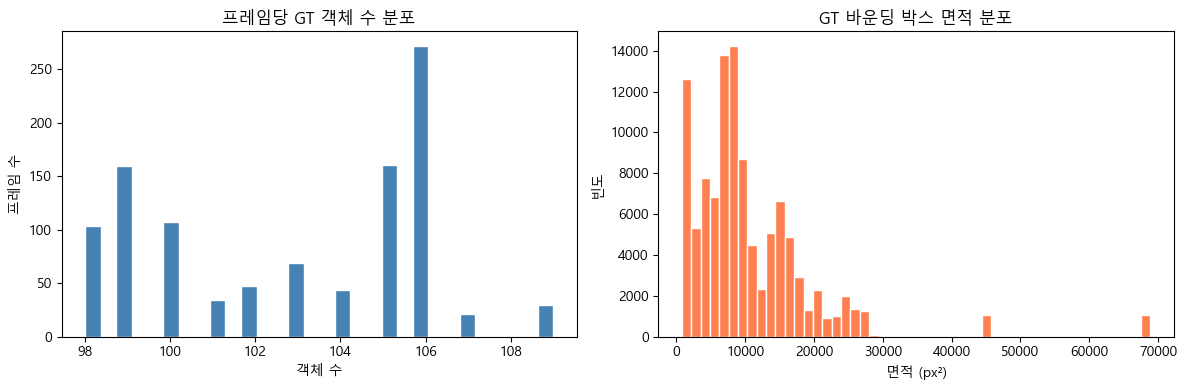

In [4]:
def load_mot_gt(gt_path: Path) -> pd.DataFrame:
    """MOT Challenge gt.txt → DataFrame.

    컬럼: frame, id, bb_left, bb_top, bb_width, bb_height, conf, x, y, z
    """
    cols = [
        "frame", "id", "bb_left", "bb_top", "bb_width", "bb_height",
        "conf", "x", "y", "z",
    ]
    df = pd.read_csv(gt_path, header=None, names=cols)
    for c in ["frame", "id", "bb_left", "bb_top", "bb_width", "bb_height"]:
        df[c] = df[c].astype(int)
    # 편의 컬럼: 박스 우하단 좌표, 중심점
    df["bb_right"] = df["bb_left"] + df["bb_width"]
    df["bb_bottom"] = df["bb_top"] + df["bb_height"]
    df["cx"] = df["bb_left"] + df["bb_width"] / 2
    df["cy"] = df["bb_top"] + df["bb_height"] / 2
    return df


# GT 어노테이션 로드
gt_df = load_mot_gt(GT_PATH)

# 첫 프레임으로 해상도 확인
sample_img = cv2.imread(str(image_paths[0]))
h, w = sample_img.shape[:2]

print("=== MOT17-04-FRCNN 요약 ===")
print(f"해상도     : {w} x {h}")
print(f"프레임 수  : {gt_df['frame'].nunique()}")
print(f"고유 추적 ID: {gt_df['id'].nunique()}")
print(f"총 GT 박스 : {len(gt_df):,}")
print(f"프레임당 평균 객체 수: {gt_df.groupby('frame').size().mean():.1f}")

# --- EDA 시각화: 프레임당 객체 수 / 박스 면적 분포 ---
per_frame = gt_df.groupby("frame").size()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(per_frame, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("프레임당 GT 객체 수 분포")
axes[0].set_xlabel("객체 수")
axes[0].set_ylabel("프레임 수")

box_areas = gt_df["bb_width"] * gt_df["bb_height"]
axes[1].hist(box_areas, bins=50, color="coral", edgecolor="white")
axes[1].set_title("GT 바운딩 박스 면적 분포")
axes[1].set_xlabel("면적 (px²)")
axes[1].set_ylabel("빈도")

plt.tight_layout()
plt.show()


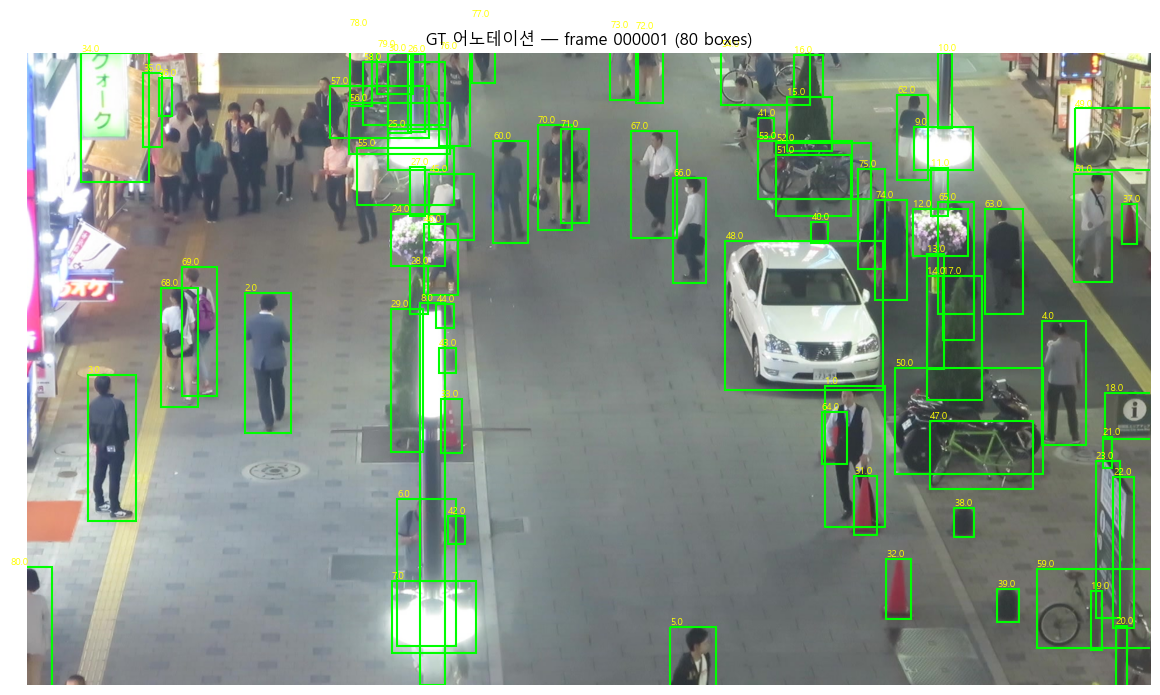

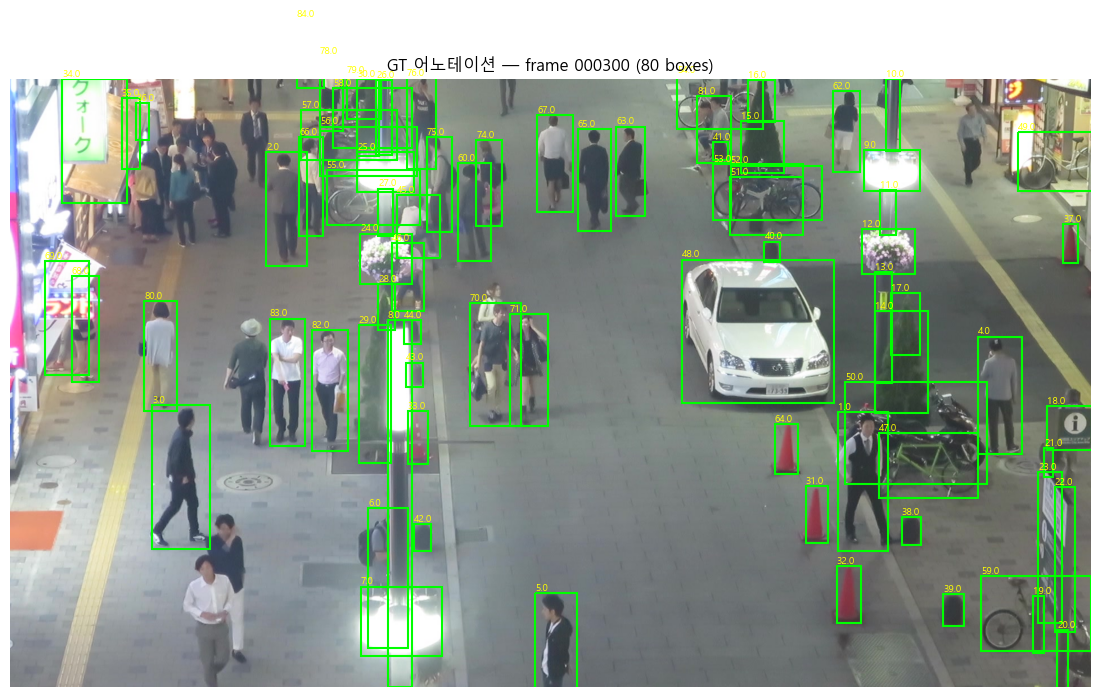

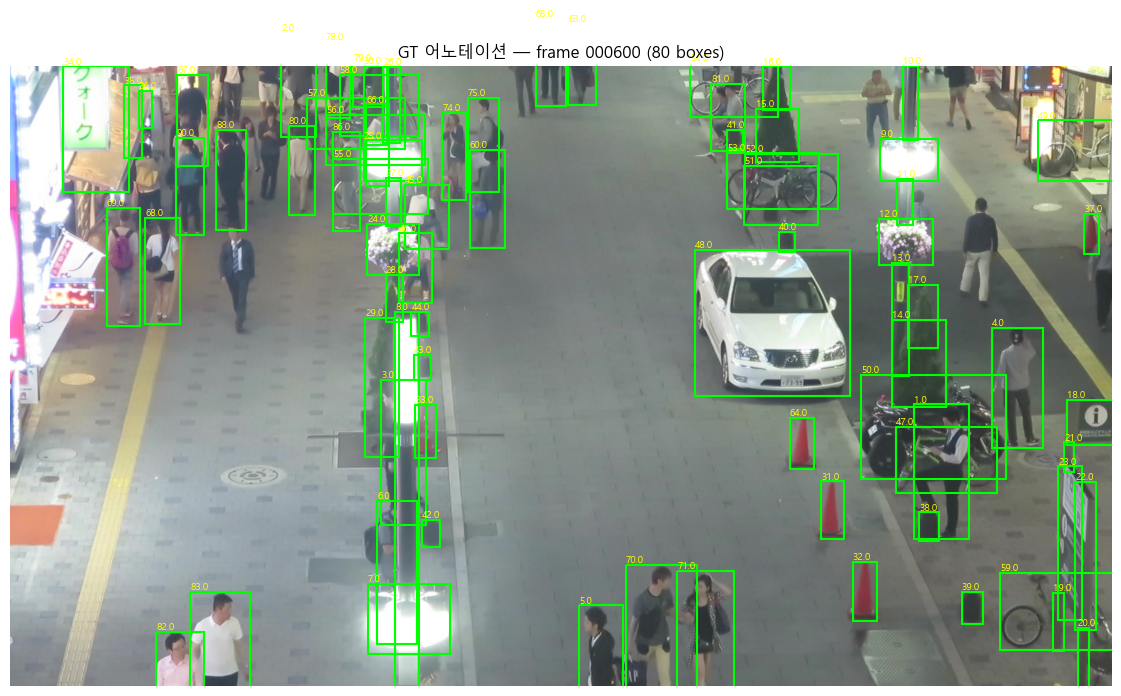

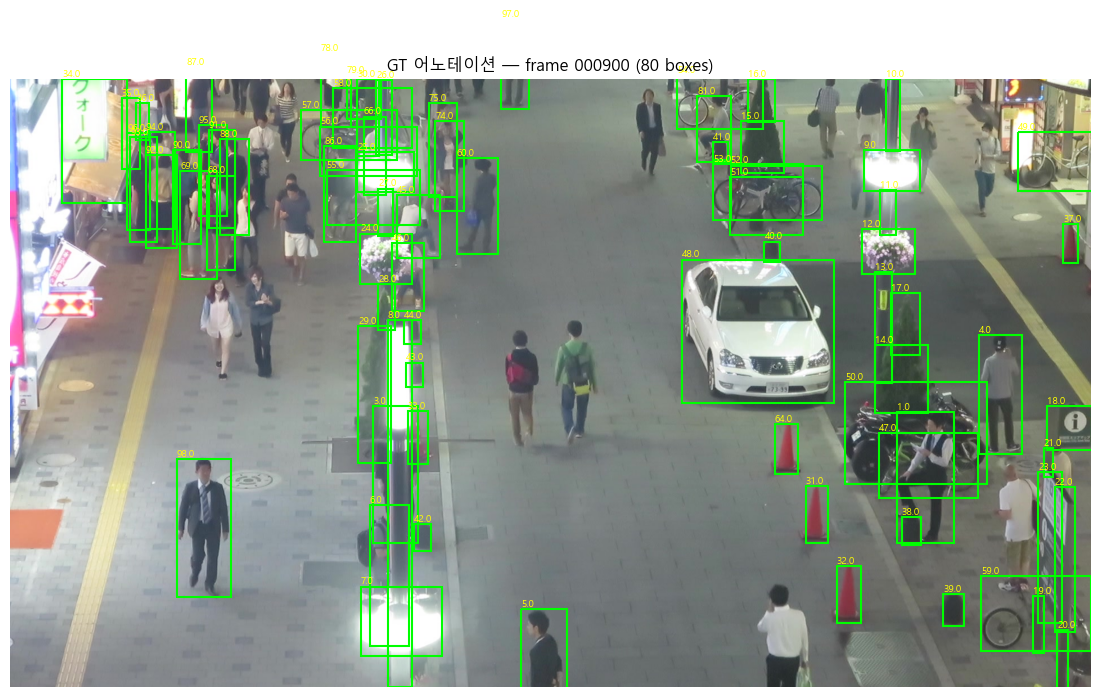

In [4]:
def draw_gt_on_frame(frame_idx: int, max_boxes: int = 80) -> None:
    """특정 프레임의 GT 바운딩 박스를 matplotlib으로 시각화."""
    img_path = IMG_DIR / f"{frame_idx:06d}.jpg"
    if not img_path.exists():
        raise FileNotFoundError(img_path)
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)  # matplotlib은 RGB 사용
    rows = gt_df[gt_df["frame"] == frame_idx].head(max_boxes)

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(img_rgb)
    for _, row in rows.iterrows():
        # GT 바운딩 박스 (초록) + 추적 ID 라벨 (노랑)
        rect = patches.Rectangle(
            (row["bb_left"], row["bb_top"]),
            row["bb_width"],
            row["bb_height"],
            linewidth=1.5,
            edgecolor="lime",
            facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(
            row["bb_left"], row["bb_top"] - 4,
            str(row["id"]), color="yellow", fontsize=7,
        )
    ax.set_title(f"GT 어노테이션 — frame {frame_idx:06d} ({len(rows)} boxes)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


# 여러 시점의 GT 어노테이션 확인
for fid in [1, 300, 600, 900]:
    draw_gt_on_frame(fid)


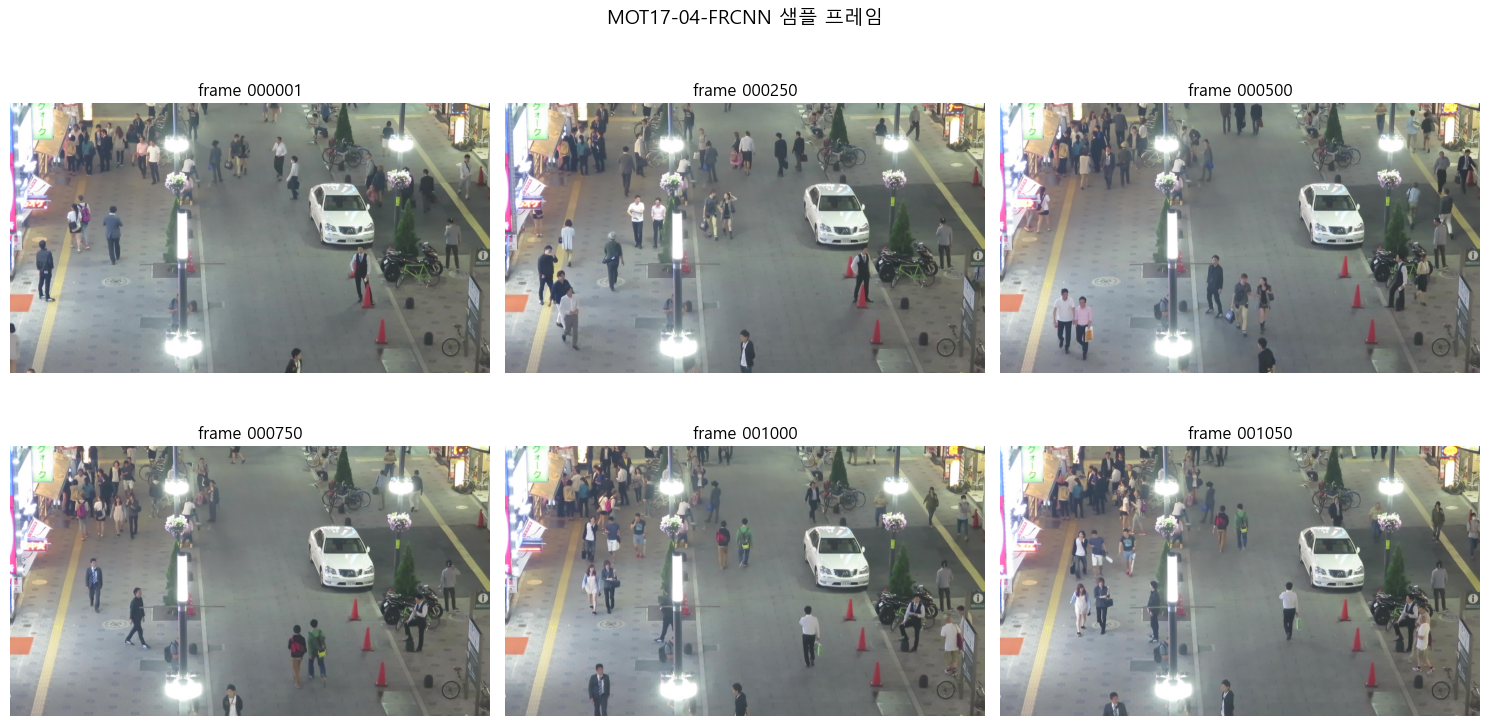

In [5]:
# 샘플 프레임 그리드 (원본 이미지, 어노테이션 없음)
sample_ids = [1, 250, 500, 750, 1000, 1050]
sample_ids = [i for i in sample_ids if i <= len(image_paths)]  # 범위 초과 제거

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, fid in zip(axes.ravel(), sample_ids):
    img = cv2.cvtColor(cv2.imread(str(IMG_DIR / f"{fid:06d}.jpg")), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"frame {fid:06d}")
    ax.axis("off")
plt.suptitle("MOT17-04-FRCNN 샘플 프레임", fontsize=14)
plt.tight_layout()
plt.show()


## 3. YOLO11 단일 프레임 Person 탐지 확인

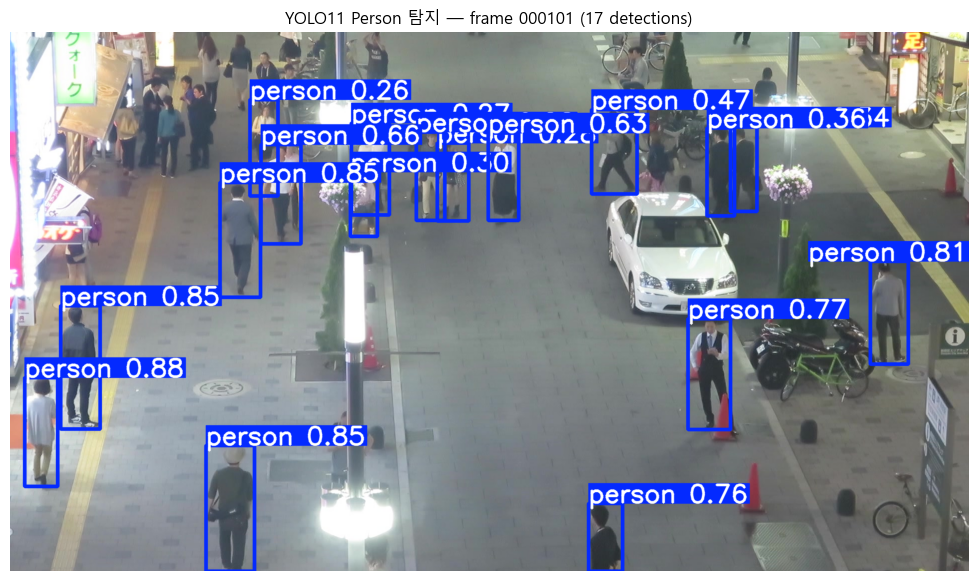

In [6]:
# YOLO11 모델 로드 (COCO 사전학습 가중치)
model = YOLO(MODEL_NAME)

# 101번째 프레임으로 person 탐지 테스트
test_frame = cv2.imread(str(image_paths[100]))
det_results = model.predict(
    test_frame,
    conf=CONF_THRESH,
    iou=IOU_THRESH,
    classes=[PERSON_CLASS],  # person(class 0)만 탐지
    device=DEVICE,
    verbose=False,
)
det_result = det_results[0]
annotated = det_result.plot()  # 탐지 결과가 그려진 이미지
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 7))
plt.imshow(annotated_rgb)
plt.title(f"YOLO11 Person 탐지 — frame 000101 ({len(det_result.boxes)} detections)")
plt.axis("off")
plt.show()


## 4. ByteTrack 추적 + 수평 기준선 카운팅 (OpenCV)

- YOLO11로 **person** 탐지 후 ByteTrack으로 **Tracking ID** 유지
- 각 객체 **중심점**이 수평 기준선을 **처음** 통과할 때 카운트 +1
- 동일 ID는 `counted_ids` 집합으로 중복 카운트 방지
- **ESC** 키로 종료

> 로컬 환경에서 OpenCV 창이 표시됩니다. Jupyter에서 창이 보이지 않으면 터미널에서 동일 코드를 실행하세요.

In [7]:
def run_tracking_and_counting(
    image_paths: list[Path],
    line_y_ratio: float = LINE_Y_RATIO,
    start_frame: int = 0,
    max_frames: int | None = None,
    window_name: str = "YOLO11 + ByteTrack | MOT17-04",
) -> dict:
    """이미지 시퀀스에 대해 YOLO11 탐지 + ByteTrack 추적 + 라인 카운팅.

    Returns:
        count, counted_ids, line_y, frames_processed 딕셔너리
    """
    tracker_model = YOLO(MODEL_NAME)

    # 처리할 프레임 목록 결정
    paths = image_paths[start_frame:]
    if max_frames is not None:
        paths = paths[:max_frames]
    if not paths:
        raise ValueError("처리할 이미지가 없습니다.")

    sample = cv2.imread(str(paths[0]))
    frame_h, frame_w = sample.shape[:2]
    line_y = int(frame_h * line_y_ratio)  # 수평 카운트 기준선 Y좌표

    count = 0                              # 누적 카운트
    counted_ids: set[int] = set()          # 이미 카운트된 추적 ID (중복 방지)
    prev_cy: dict[int, float] = {}         # ID별 이전 프레임 중심점 Y좌표
    frame_idx = start_frame

    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(window_name, min(1280, frame_w), min(720, frame_h))

    try:
        for img_path in paths:
            frame = cv2.imread(str(img_path))
            if frame is None:
                continue

            # YOLO11 탐지 + ByteTrack 추적 (persist=True: 프레임 간 ID 유지)
            results = tracker_model.track(
                frame,
                persist=True,
                tracker=TRACKER,
                conf=CONF_THRESH,
                iou=IOU_THRESH,
                classes=[PERSON_CLASS],
                device=DEVICE,
                verbose=False,
            )
            result = results[0]
            vis = frame.copy()  # 시각화용 복사본

            if result.boxes is not None and len(result.boxes):
                boxes = result.boxes.xyxy.cpu().numpy()   # [x1,y1,x2,y2]
                confs = result.boxes.conf.cpu().numpy()   # 신뢰도
                track_ids = result.boxes.id               # ByteTrack ID

                if track_ids is not None:
                    track_ids = track_ids.cpu().numpy().astype(int)
                    for box, tid, conf in zip(boxes, track_ids, confs):
                        x1, y1, x2, y2 = map(int, box)
                        cx = int((x1 + x2) / 2)  # 바운딩 박스 중심 X
                        cy = int((y1 + y2) / 2)  # 바운딩 박스 중심 Y

                        # --- 라인 카운팅: 이전 프레임과 기준선 양쪽에 있으면 +1 ---
                        if tid not in counted_ids and tid in prev_cy:
                            prev = prev_cy[tid]
                            # 위→아래 또는 아래→위 첫 통과 시 카운트
                            if (prev < line_y <= cy) or (prev > line_y >= cy):
                                count += 1
                                counted_ids.add(tid)
                        prev_cy[tid] = cy  # 다음 프레임 비교용 저장

                        # 카운트 완료 ID는 초록, 미완료는 노랑 bbox
                        color = (0, 255, 0) if tid in counted_ids else (0, 200, 255)
                        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
                        label = f"ID:{tid} {conf:.2f}"
                        cv2.putText(
                            vis, label, (x1, max(y1 - 8, 0)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2,
                        )
                        cv2.circle(vis, (cx, cy), 4, (0, 0, 255), -1)  # 중심점

            # 수평 카운트 기준선 (빨강)
            cv2.line(vis, (0, line_y), (frame_w, line_y), (0, 0, 255), 2)
            cv2.putText(
                vis, "Count Line", (10, line_y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2,
            )
            # 좌상단 누적 카운트 (진한 빨강)
            cv2.putText(
                vis, f"Count: {count}", (20, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 200), 3,
            )
            # 하단 프레임 정보
            cv2.putText(
                vis, f"Frame: {frame_idx + 1}/{len(image_paths)}  [ESC: quit]",
                (20, frame_h - 20), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2,
            )

            cv2.imshow(window_name, vis)
            key = cv2.waitKey(1) & 0xFF
            if key == 27:  # ESC 키 → 종료
                print("ESC — 종료")
                break
            frame_idx += 1
    finally:
        cv2.destroyAllWindows()

    return {
        "count": count,
        "counted_ids": sorted(counted_ids),
        "line_y": line_y,
        "frames_processed": frame_idx - start_frame,
    }


In [10]:
# 전체 시퀀스 실행 (ESC로 조기 종료 가능)
# 테스트 시 max_frames=200 등으로 제한할 수 있습니다.
# RTX 3060 : 약 1분 소요
# CPU      : 약 4분 소요
stats = run_tracking_and_counting(
    image_paths,
    line_y_ratio=LINE_Y_RATIO,
    start_frame=0,
    max_frames=None,  # None = 전체 1050프레임
)

print("=== 카운팅 결과 ===")
print(f"기준선 Y   : {stats['line_y']} px")
print(f"처리 프레임: {stats['frames_processed']}")
print(f"총 카운트  : {stats['count']}")
print(f"카운트된 ID 수: {len(stats['counted_ids'])}")


=== 카운팅 결과 ===
기준선 Y   : 594 px
처리 프레임: 1050
총 카운트  : 12
카운트된 ID 수: 12


## 5. (선택) 결과 프레임 Jupyter 미리보기

OpenCV 창 대신 노트북에서 정지 화면으로 결과를 확인할 때 사용합니다.

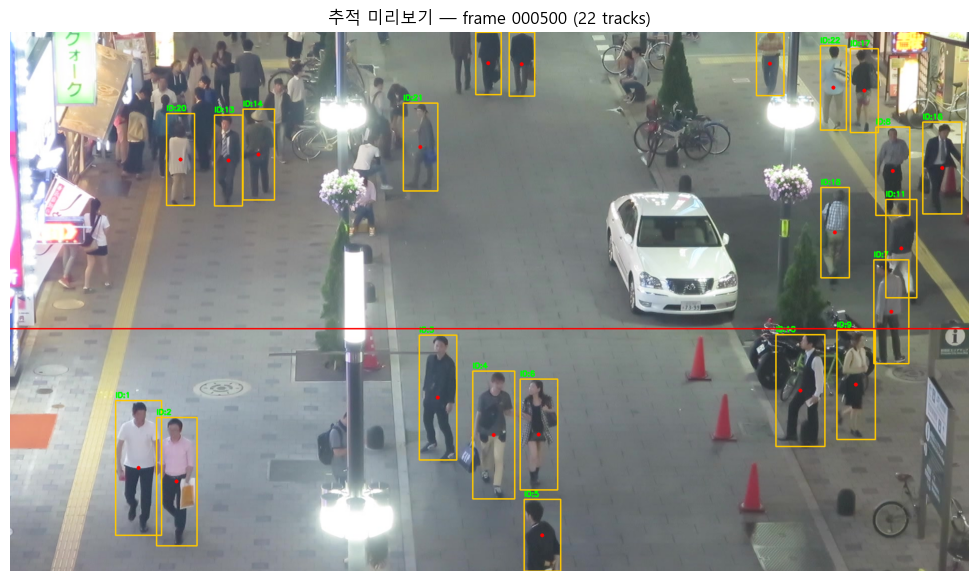

In [9]:
def preview_tracking_frame(frame_number: int = 500, line_y_ratio: float = LINE_Y_RATIO) -> None:
    """단일 프레임에 탐지·추적 결과를 렌더링해 노트북에 표시.

    OpenCV 창 없이 정지 화면으로 확인할 때 사용.
    주의: 단일 프레임만 처리하므로 누적 Count는 포함되지 않음.
    """
    preview_model = YOLO(MODEL_NAME)
    img_path = IMG_DIR / f"{frame_number:06d}.jpg"
    frame = cv2.imread(str(img_path))
    h, w = frame.shape[:2]
    line_y = int(h * line_y_ratio)

    results = preview_model.track(
        frame,
        persist=True,
        tracker=TRACKER,
        conf=CONF_THRESH,
        classes=[PERSON_CLASS],
        device=DEVICE,
        verbose=False,
    )
    vis = frame.copy()
    result = results[0]

    n_tracks = 0
    if result.boxes is not None and result.boxes.id is not None:
        boxes = result.boxes.xyxy.cpu().numpy()
        ids = result.boxes.id.cpu().numpy().astype(int)
        n_tracks = len(ids)
        for box, tid in zip(boxes, ids):
            x1, y1, x2, y2 = map(int, box)
            cx, cy = int((x1 + x2) / 2), int((y1 + y2) / 2)
            cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 200, 255), 2)
            cv2.putText(vis, f"ID:{tid}", (x1, y1 - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
            cv2.circle(vis, (cx, cy), 4, (0, 0, 255), -1)

    cv2.line(vis, (0, line_y), (w, line_y), (0, 0, 255), 2)  # 카운트 기준선
    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(14, 7))
    plt.imshow(vis_rgb)
    plt.title(f"추적 미리보기 — frame {frame_number:06d} ({n_tracks} tracks)")
    plt.axis("off")
    plt.show()


# 500번 프레임 미리보기
preview_tracking_frame(500)
